<a href="https://colab.research.google.com/github/SastaGhost/data-analytics-project/blob/main/Collage_Admission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving College_admission.csv to College_admission.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
df = pd.read_csv("College_admission.csv")

df.head()

,admit,gre,gpa,ses,Gender_Male,Race,rank
0,0,380,3.61,1,0,3,3
1,1,660,3.67,2,0,2,3
2,1,800,4.00,2,0,2,1
3,1,640,3.19,1,1,2,4
4,0,520,2.93,3,1,2,4


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape: (400, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   admit        400 non-null    int64  
 1   gre          400 non-null    int64  
 2   gpa          400 non-null    float64
 3   ses          400 non-null    int64  
 4   Gender_Male  400 non-null    int64  
 5   Race         400 non-null    int64  
 6   rank         400 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 22.0 KB


,0
admit,0
gre,0
gpa,0
ses,0
Gender_Male,0
Race,0
rank,0


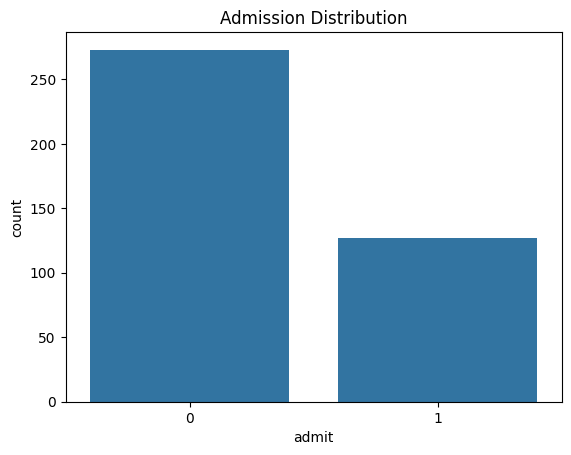

In [5]:
sns.countplot(x='admit', data=df)
plt.title("Admission Distribution")
plt.show()

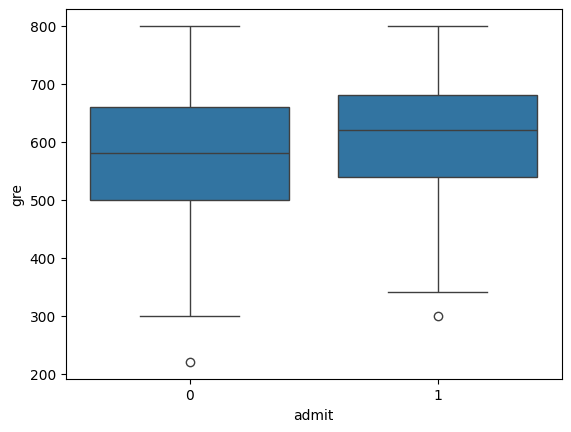

In [6]:
sns.boxplot(x='admit', y='gre', data=df)
plt.show()

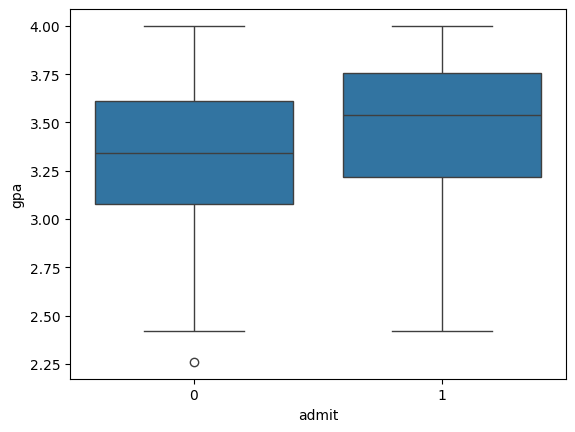

In [7]:
sns.boxplot(x='admit', y='gpa', data=df)
plt.show()

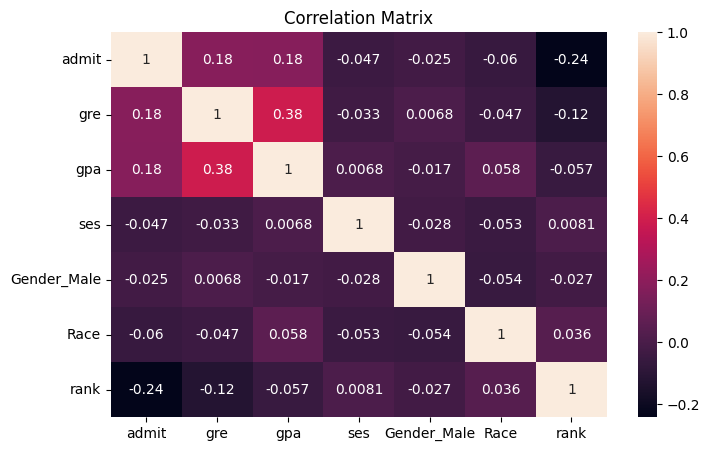

In [8]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

In [9]:
X = df.drop("admit", axis=1)

y = df["admit"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = LogisticRegression()

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [12]:
pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6625


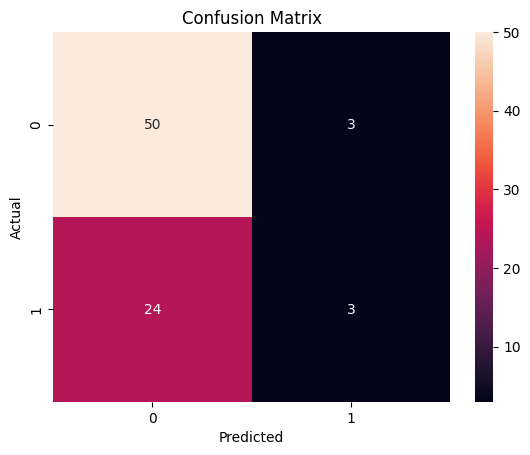

In [14]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [15]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.68      0.94      0.79        53
           1       0.50      0.11      0.18        27

    accuracy                           0.66        80
   macro avg       0.59      0.53      0.48        80
weighted avg       0.62      0.66      0.58        80



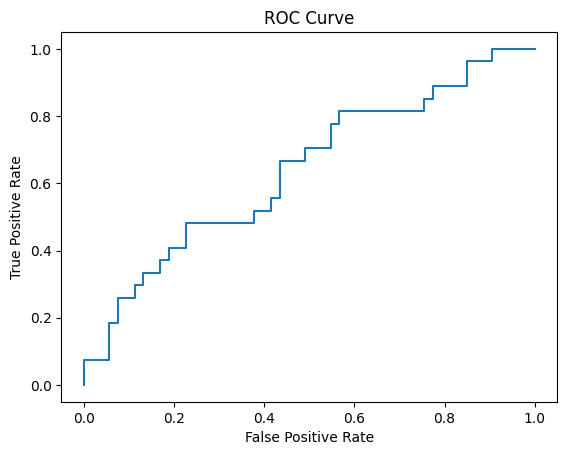

ROC AUC Score: 0.6387141858839971


In [16]:
prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, prob))